In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/CS2441/patches.zip -d /content/

print("Patches unzipped successfully!")

import os

folders = [
    "/content/patches/water/rgb",
    "/content/patches/water/mask",
    "/content/patches/no_water/rgb",
    "/content/patches/no_water/mask"
]

for folder in folders:
    status = "YES" if os.path.isdir(folder) else "NOT FOUND"
    print(f"   {status}  {folder}")

Patches unzipped successfully!
   YES  /content/patches/water/rgb
   YES  /content/patches/water/mask
   YES  /content/patches/no_water/rgb
   YES  /content/patches/no_water/mask


In [ ]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np

from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from tqdm import tqdm

print("All libraries imported successfully!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU name        : {torch.cuda.get_device_name(0)}")
else:
    print("   No GPU found.")

All libraries imported successfully!
   PyTorch version : 2.11.0+cu128
   GPU available   : True
   GPU name        : Tesla T4


In [ ]:
DEVICE = torch.device("cuda")

BASE_DIR         = "/content/patches"

WATER_RGB_DIR    = os.path.join(BASE_DIR, "water",    "rgb")
WATER_MASK_DIR   = os.path.join(BASE_DIR, "water",    "mask")
NOWATER_RGB_DIR  = os.path.join(BASE_DIR, "no_water", "rgb")
NOWATER_MASK_DIR = os.path.join(BASE_DIR, "no_water", "mask")

OUTPUT_DIR       = "/content/cnn_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PATCH_SIZE   = 128
NUM_CHANNELS = 3
NUM_CLASSES  = 2

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

BATCH_SIZE    = 16
NUM_EPOCHS    = 25
LEARNING_RATE = 1e-4

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

print("Configuration set!")
print(f"   Device        : {DEVICE}")
print(f"   Batch size    : {BATCH_SIZE}")
print(f"   Epochs        : {NUM_EPOCHS}")
print(f"   Learning rate : {LEARNING_RATE}")
print(f"   Output folder : {OUTPUT_DIR}")
print()
print("Checking patch folders...")
for name, path in [("water/rgb",     WATER_RGB_DIR),
                   ("water/mask",    WATER_MASK_DIR),
                   ("no_water/rgb",  NOWATER_RGB_DIR),
                   ("no_water/mask", NOWATER_MASK_DIR)]:
    status = "YES" if os.path.isdir(path) else "NOT FOUND"
    print(f"   {status}  {name}")

Configuration set!
   Device        : cuda
   Batch size    : 16
   Epochs        : 25
   Learning rate : 0.0001
   Output folder : /content/cnn_output

Checking patch folders...
   YES  water/rgb
   YES  water/mask
   YES  no_water/rgb
   YES  no_water/mask


In [ ]:
water_rgb_files   = sorted(glob.glob(os.path.join(WATER_RGB_DIR,   "*.png")))
nowater_rgb_files = sorted(glob.glob(os.path.join(NOWATER_RGB_DIR, "*.png")))

print(f"Files collected!")
print(f"   Water patches    : {len(water_rgb_files)}")
print(f"   No-Water patches : {len(nowater_rgb_files)}")
print(f"   Total            : {len(water_rgb_files) + len(nowater_rgb_files)}")

Files collected!
   Water patches    : 3651
   No-Water patches : 3574
   Total            : 7225


In [ ]:
water_data   = [(path, 1) for path in water_rgb_files]
nowater_data = [(path, 0) for path in nowater_rgb_files]

all_data = water_data + nowater_data

random.shuffle(all_data)

print(f"Data combined and shuffled!")
print(f"   Total samples : {len(all_data)}")
print(f"   Water   (1)   : {sum(1 for _, label in all_data if label == 1)}")
print(f"   No-Water(0)   : {sum(1 for _, label in all_data if label == 0)}")

Data combined and shuffled!
   Total samples : 7225
   Water   (1)   : 3651
   No-Water(0)   : 3574


In [ ]:
n_total = len(all_data)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_data = all_data[:n_train]
val_data   = all_data[n_train : n_train + n_val]
test_data  = all_data[n_train + n_val:]

print(f"Data split done!")
print(f"   Total : {n_total}")
print(f"   Train : {n_train}  ({TRAIN_RATIO*100:.0f}%)")
print(f"   Val   : {n_val}    ({VAL_RATIO*100:.0f}%)")
print(f"   Test  : {n_test}   ({TEST_RATIO*100:.0f}%)")

Data split done!
   Total : 7225
   Train : 5057  (70%)
   Val   : 1083    (15%)
   Test  : 1085   (15%)


In [ ]:
class WaterClassificationDataset(Dataset):

    def __init__(self, data, augment=False):
        self.data    = data
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]

        img = Image.open(path).convert("RGB")

        if self.augment:
            if random.random() > 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                img = img.transpose(Image.FLIP_TOP_BOTTOM)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                img   = img.rotate(angle)

        img = np.array(img, dtype=np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1)

        label = torch.tensor(label, dtype=torch.long)

        return img, label

print("WaterClassificationDataset class defined!")
print("   Image tensor shape : (3, 128, 128)")
print("   Label              : 0 = no water | 1 = water")

WaterClassificationDataset class defined!
   Image tensor shape : (3, 128, 128)
   Label              : 0 = no water | 1 = water


In [ ]:
train_dataset = WaterClassificationDataset(train_data, augment=True)
val_dataset   = WaterClassificationDataset(val_data,   augment=False)
test_dataset  = WaterClassificationDataset(test_data,  augment=False)

print("Datasets created!")
print(f"   Train dataset : {len(train_dataset)} patches")
print(f"   Val dataset   : {len(val_dataset)} patches")
print(f"   Test dataset  : {len(test_dataset)} patches")

Datasets created!
   Train dataset : 5057 patches
   Val dataset   : 1083 patches
   Test dataset  : 1085 patches


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

DataLoaders created!
   Train batches : 317
   Val batches   : 68
   Test batches  : 68


In [ ]:
class WaterCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = self.conv_block(3,   32)
        self.conv2 = self.conv_block(32,  64)
        self.conv3 = self.conv_block(64,  128)
        self.conv4 = self.conv_block(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.fc1     = nn.Linear(256 * 8 * 8, 512)
        self.fc2     = nn.Linear(512, 128)
        self.fc3     = nn.Linear(128, 2)

        self.dropout = nn.Dropout(0.5)

        self.relu    = nn.ReLU()

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        x = self.pool(self.conv1(x))
        x = self.pool(self.conv2(x))
        x = self.pool(self.conv3(x))
        x = self.pool(self.conv4(x))
        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

print("CNN architecture defined!")

CNN architecture defined!


In [ ]:
criterion = nn.CrossEntropyLoss()

print("Loss function defined!")
print("   Loss : CrossEntropyLoss")

Loss function defined!
   Loss : CrossEntropyLoss


In [ ]:
model     = WaterCNN().to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Model ready!")
print(f"   Model     : WaterCNN")
print(f"   Loss      : CrossEntropyLoss")
print(f"   Optimiser : Adam")
print(f"   LR        : {LEARNING_RATE}")

total_params = sum(p.numel() for p in model.parameters())
print(f"   Parameters: {total_params:,}")

Model ready!
   Model     : WaterCNN
   Loss      : CrossEntropyLoss
   Optimiser : Adam
   LR        : 0.0001
   Parameters: 8,844,418


In [ ]:
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

best_val_acc    = 0.0
best_model_path = os.path.join(OUTPUT_DIR, "best_cnn.pth")

print("Training started!")
print(f"   Epochs     : {NUM_EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()
    train_loss = 0.0
    train_acc  = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds     = outputs.argmax(dim=1)
        acc       = (preds == labels).float().mean()

        train_loss += loss.item()
        train_acc  += acc.item()

    model.eval()
    val_loss = 0.0
    val_acc  = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss    = criterion(outputs, labels)
            preds   = outputs.argmax(dim=1)
            acc     = (preds == labels).float().mean()

            val_loss += loss.item()
            val_acc  += acc.item()

    train_loss /= len(train_loader)
    train_acc  /= len(train_loader)
    val_loss   /= len(val_loader)
    val_acc    /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved = "saved"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {saved}")

Training started!
   Epochs     : 25
   Batch size : 16
------------------------------------------------------------


Epoch 1/25 [Train]: 100%|██████████| 317/317 [00:14<00:00, 21.77it/s]


Epoch 01/25 | Train Loss: 0.6996 | Train Acc: 0.5739 | Val Loss: 0.6279 | Val Acc: 0.6147 saved


Epoch 2/25 [Train]: 100%|██████████| 317/317 [00:11<00:00, 26.68it/s]


Epoch 02/25 | Train Loss: 0.6492 | Train Acc: 0.6159 | Val Loss: 0.6238 | Val Acc: 0.6395 saved


...

Epoch 23/25 | Train Loss: 0.5322 | Train Acc: 0.7169 | Val Loss: 0.5412 | Val Acc: 0.7046 


Epoch 24/25 [Train]: 100%|██████████| 317/317 [00:11<00:00, 27.38it/s]


Epoch 24/25 | Train Loss: 0.5361 | Train Acc: 0.7133 | Val Loss: 0.5282 | Val Acc: 0.7010 


Epoch 25/25 [Train]: 100%|██████████| 317/317 [00:11<00:00, 27.19it/s]


Epoch 25/25 | Train Loss: 0.5297 | Train Acc: 0.7139 | Val Loss: 0.5348 | Val Acc: 0.7084 


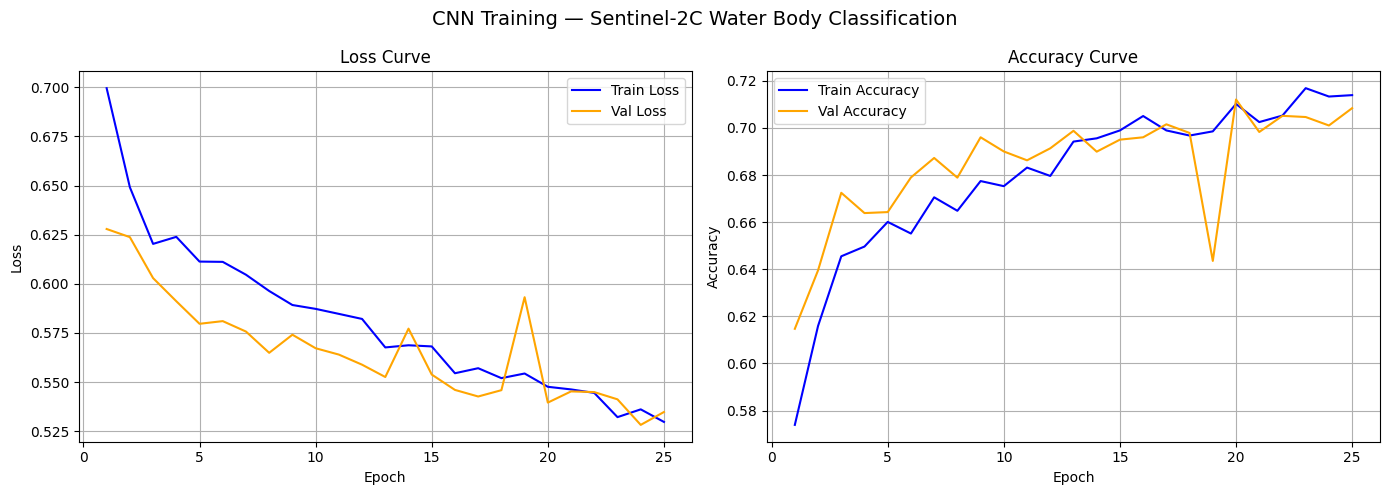

Training curves saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="blue")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="orange")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["train_acc"], label="Train Accuracy", color="blue")
axes[1].plot(epochs, history["val_acc"],   label="Val Accuracy",   color="orange")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("CNN Training — Sentinel-2C Water Body Classification", fontsize=14)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Training curves saved!")

In [ ]:
best_model_path = os.path.join(OUTPUT_DIR, "best_cnn.pth")

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

print("Best CNN model loaded!")
print(f"From: {best_model_path}")
print()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing CNN"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("CNN Test Results")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-score  : {f1:.4f} ({f1 * 100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["No Water", "Water"]
))

Best CNN model loaded!
From: /content/cnn_output/best_cnn.pth



Testing CNN: 100%|██████████| 68/68 [00:04<00:00, 16.89it/s]


CNN Test Results
----------------------------------------
Accuracy  : 0.7318 (73.18%)
Precision : 0.7111 (71.11%)
Recall    : 0.8043 (80.43%)
F1-score  : 0.7548 (75.48%)

Classification Report:
              precision    recall  f1-score   support

    No Water       0.76      0.66      0.70       528
       Water       0.71      0.80      0.75       557

    accuracy                           0.73      1085
   macro avg       0.74      0.73      0.73      1085
weighted avg       0.74      0.73      0.73      1085



In [ ]:
class CNNGradCAM:

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.forward_handle = target_layer.register_forward_hook(
            self.save_activations
        )
        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradients
        )

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, target_class=1):
        self.model.eval()

        output = self.model(input_tensor)
        score = output[:, target_class].sum()

        self.model.zero_grad()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


print("CNN Grad-CAM class ready!")

CNN Grad-CAM class ready!


In [ ]:
cnn_gradcam_dir = os.path.join(OUTPUT_DIR, "gradcam")
os.makedirs(cnn_gradcam_dir, exist_ok=True)

gradcam = CNNGradCAM(model, model.conv4)


water_test_items = [(path, label) for path, label in test_data if label == 1]

print(f"Water test patches found: {len(water_test_items)}")
print(f"Saving CNN Grad-CAM images to: {cnn_gradcam_dir}")
print()

for count, (path, true_label) in enumerate(water_test_items[:20]):

    img = Image.open(path).convert("RGB")
    img_np = np.array(img, dtype=np.float32) / 255.0

    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred_label = output.argmax(dim=1).item()
    water_prob = probs[0, 1].item()

    cam = gradcam.generate(img_tensor, target_class=1)

    rgb = np.clip(img_np, 0, 1)
    rgb_vis = rgb.copy()

    for c in range(3):
        p2 = np.percentile(rgb_vis[:, :, c], 2)
        p98 = np.percentile(rgb_vis[:, :, c], 98)
        rgb_vis[:, :, c] = np.clip(
            (rgb_vis[:, :, c] - p2) / (p98 - p2 + 1e-8),
            0,
            1
        )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.patch.set_facecolor("white")

    axes[0].imshow(rgb_vis)
    axes[0].set_title("Input Patch", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(rgb_vis)
    heatmap = axes[1].imshow(cam, cmap="jet", alpha=0.55, vmin=0, vmax=1)
    axes[1].set_title("CNN Grad-CAM for Water Class", fontsize=12, fontweight="bold")
    axes[1].axis("off")

    cbar = plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label("Importance", rotation=270, labelpad=15, fontsize=9)

    axes[2].bar(["No Water", "Water"], probs.squeeze().detach().cpu().numpy(),
                color=["gray", "royalblue"])
    axes[2].set_ylim(0, 1)
    axes[2].set_title("CNN Prediction", fontsize=12, fontweight="bold")
    axes[2].set_ylabel("Probability")
    axes[2].grid(axis="y", alpha=0.3)

    pred_name = "Water" if pred_label == 1 else "No Water"

    plt.suptitle(
        f"CNN Grad-CAM - Sentinel-2C | Sample {count + 1:02d} | "
        f"Predicted: {pred_name} | Water Prob: {water_prob:.3f}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    save_path = os.path.join(cnn_gradcam_dir, f"cnn_gradcam_{count + 1:02d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close()

print(f"CNN Grad-CAM images saved: {min(len(water_test_items), 20)}")
print(f"Location: {cnn_gradcam_dir}")

gradcam.remove_hooks()

Water test patches found: 557
Saving CNN Grad-CAM images to: /content/cnn_output/gradcam

CNN Grad-CAM images saved: 20
Location: /content/cnn_output/gradcam


In [ ]:
import shutil

src = "/content/cnn_output"
dst = "/content/drive/MyDrive/CS2441/cnn_output"

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("CNN output folder copied to Drive!")
print(f"From: {src}")
print(f"To  : {dst}")

CNN output folder copied to Drive!
From: /content/cnn_output
To  : /content/drive/MyDrive/CS2441/cnn_output
